# XGBoost LOBO Training

This notebook merges the benchmark CSV files, builds `edge_prob = prob_num / prob_den`, and runs leave-one-benchmark-out evaluation with XGBoost.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


## Set input CSV paths
Update these paths to wherever the benchmark CSV files are on your machine.

In [2]:
CSV_FILES = {
    "perlbench": "perlbench_all_edges_clean.csv",
    "gcc": "gcc_all_edges_clean.csv",
    "mcf": "mcf_all_edges_clean.csv",
    "omnetpp": "omnetpp_all_edges_clean.csv",
    "x264": "x264_all_edges_clean.csv",
    "deepsjeng": "deepsjeng_all_edges_clean.csv",
    "xz": "xz_all_edges_clean.csv",
}

OUT_DIR = Path("./modeling_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Merge CSVs and add benchmark label

In [3]:
dfs = []
for benchmark, path in CSV_FILES.items():
    df = pd.read_csv(path)
    df["benchmark"] = benchmark
    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)
# master_df.to_csv(OUT_DIR / "master_dataset.csv", index=False)
print("Total rows:", len(master_df))
master_df.head()


Total rows: 269355


,func,src_bb,dst_bb,succ_idx,prob_num,prob_den,src_prof_count,dst_prof_count,edge_count_est,is_back_edge,...,dst_fracPhiNodes,dst_maxPhiIncoming,dst_avgPhiIncomingEdges,dst_numParentBlocks,dst_avgValueUsage,dst_maxValueUsage,dst_numVarsUsed,dst_entranceDistance,dst_exitDistance,benchmark
0,boot_DynaLoader,<unnamed>,<unnamed>,0,0,2147483648,3,3,0,0,...,0.0,0,0.0,2,0.750000,2,9,1,0,perlbench
1,boot_DynaLoader,<unnamed>,<unnamed>,1,2147483648,2147483648,3,3,3,0,...,0.0,0,0.0,1,0.333333,1,5,1,1,perlbench
2,boot_DynaLoader,<unnamed>,<unnamed>,0,2147483648,2147483648,3,3,3,0,...,0.0,0,0.0,2,0.750000,2,9,1,0,perlbench
3,XS_DynaLoader_dl_error,<unnamed>,<unnamed>,0,805306368,2147483648,0,0,0,0,...,0.0,0,0.0,2,1.000000,2,11,1,3,perlbench
4,XS_DynaLoader_dl_error,<unnamed>,<unnamed>,1,1342177280,2147483648,0,0,0,0,...,0.0,0,0.0,1,0.000000,0,4,1,4,perlbench


## Create target edge probability

In [4]:
master_df["edge_prob"] = master_df["prob_num"].astype(float) / master_df["prob_den"].astype(float)
master_df = master_df.replace([float('inf'), float('-inf')], np.nan)
master_df = master_df.dropna(subset=["edge_prob"]).copy()
master_df = master_df[(master_df["edge_prob"] >= 0.0) & (master_df["edge_prob"] <= 1.0)].copy()

print("Rows after filtering:", len(master_df))
master_df["edge_prob"].describe()


Rows after filtering: 269355


count    269355.000000
mean          0.598259
std           0.358077
min           0.000000
25%           0.375000
50%           0.500000
75%           1.000000
max           1.000000
Name: edge_prob, dtype: float64

## Select features

In [5]:
exclude_cols = {
    "func",
    "src_bb",
    "dst_bb",
    "benchmark",
    "prob_num",
    "prob_den",
    "edge_prob",
    "src_prof_count",
    "dst_prof_count",
    "edge_count_est",
}

feature_cols = [c for c in master_df.columns if c not in exclude_cols]

for col in feature_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

medians = master_df[feature_cols].median()
master_df[feature_cols] = master_df[feature_cols].fillna(medians)

print("Number of feature columns:", len(feature_cols))
feature_cols[:20]


Number of feature columns: 67


['succ_idx',
 'is_back_edge',
 'dst_is_loop_header',
 'src_numInstr',
 'src_loopDepth',
 'src_finalOpcode',
 'src_numSuccessors',
 'src_fracLoads',
 'src_fracStores',
 'src_fracAllocs',
 'src_fracOtherMem',
 'src_fracArith',
 'src_fracIArith',
 'src_fracFArith',
 'src_fracCalls',
 'src_fracCasts',
 'src_numICmps',
 'src_numPtrCmps',
 'src_numBothPtrUnknown',
 'src_numPtrCmpNull']

In [6]:
master_df["benchmark"].value_counts()


perlbench    127013
omnetpp       79162
gcc           34813
x264          17739
xz             5538
deepsjeng      4064
mcf            1026
Name: benchmark, dtype: int64

## Leave-one-benchmark-out evaluation

In [7]:
results = []

benchmarks = sorted(master_df["benchmark"].unique())

for test_benchmark in benchmarks:
    train_df = master_df[master_df["benchmark"] != test_benchmark].copy()
    test_df = master_df[master_df["benchmark"] == test_benchmark].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["edge_prob"]
    X_test = test_df[feature_cols]
    y_test = test_df["edge_prob"]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0.0, 1.0)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    y_test_np = np.asarray(y_test)
    y_pred_np = np.asarray(y_pred)

    if np.std(y_test_np) == 0 or np.std(y_pred_np) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(y_test_np, y_pred_np)[0, 1]

    row = {
        "benchmark": test_benchmark,
        "n_train": int(len(train_df)),
        "n_test": int(len(test_df)),
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "corr": float(corr) if not np.isnan(corr) else np.nan,
    }
    results.append(row)

    print(
        f"[LOBO] test={test_benchmark:>10} | "
        f"n_train={len(train_df):>8} | "
        f"n_test={len(test_df):>8} | "
        f"MAE={mae:.6f} | "
        f"RMSE={rmse:.6f} | "
        f"R2={r2:.6f} | "
        f"Corr={corr:.6f}"
    )

results_df = pd.DataFrame(results).sort_values("benchmark").reset_index(drop=True)
results_df

[LOBO] test= deepsjeng | n_train=  265291 | n_test=    4064 | MAE=0.225386 | RMSE=0.309848 | R2=0.342082 | Corr=0.588403
[LOBO] test=       gcc | n_train=  234542 | n_test=   34813 | MAE=0.090536 | RMSE=0.158598 | R2=0.788472 | Corr=0.889069
[LOBO] test=       mcf | n_train=  268329 | n_test=    1026 | MAE=0.230917 | RMSE=0.316786 | R2=0.443375 | Corr=0.666796
[LOBO] test=   omnetpp | n_train=  190193 | n_test=   79162 | MAE=0.180801 | RMSE=0.282610 | R2=0.464741 | Corr=0.694213
[LOBO] test= perlbench | n_train=  142342 | n_test=  127013 | MAE=0.125036 | RMSE=0.211863 | R2=0.616450 | Corr=0.785393
[LOBO] test=      x264 | n_train=  251616 | n_test=   17739 | MAE=0.130384 | RMSE=0.212225 | R2=0.617144 | Corr=0.786707
[LOBO] test=        xz | n_train=  263817 | n_test=    5538 | MAE=0.126686 | RMSE=0.210990 | R2=0.667204 | Corr=0.818155


,benchmark,n_train,n_test,mae,rmse,r2,corr
0,deepsjeng,265291,4064,0.225386,0.309848,0.342082,0.588403
1,gcc,234542,34813,0.090536,0.158598,0.788472,0.889069
2,mcf,268329,1026,0.230917,0.316786,0.443375,0.666796
3,omnetpp,190193,79162,0.180801,0.282610,0.464741,0.694213
4,perlbench,142342,127013,0.125036,0.211863,0.616450,0.785393
5,x264,251616,17739,0.130384,0.212225,0.617144,0.786707
6,xz,263817,5538,0.126686,0.210990,0.667204,0.818155


In [9]:
results_df.describe()
print(results_df["mae"].mean())
print(results_df["corr"].mean())

0.15853502740959452
0.7469623575787087


## Save results

In [10]:
results_df.to_csv(OUT_DIR / "lobo_results.csv", index=False)

summary = {
    "n_rows": int(len(master_df)),
    "n_features": int(len(feature_cols)),
    "benchmarks": benchmarks,
    "mean_mae": float(results_df["mae"].mean()),
    "mean_rmse": float(results_df["rmse"].mean()),
    "mean_r2": float(results_df["r2"].mean()),
    "mean_corr": float(results_df["corr"].mean()),
    "median_mae": float(results_df["mae"].median()),
    "median_rmse": float(results_df["rmse"].median()),
    "median_r2": float(results_df["r2"].median()),
    "median_corr": float(results_df["corr"].median()),
    "std_corr": float(results_df["corr"].std()),
    "feature_columns": feature_cols,
}

with open(OUT_DIR / "lobo_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'n_rows': 269355,
 'n_features': 67,
 'benchmarks': ['deepsjeng',
  'gcc',
  'mcf',
  'omnetpp',
  'perlbench',
  'x264',
  'xz'],
 'mean_mae': 0.15853502740959452,
 'mean_rmse': 0.2432744419924139,
 'mean_r2': 0.5627814549726601,
 'mean_corr': 0.7469623575787087,
 'median_mae': 0.13038351675664034,
 'median_rmse': 0.21222495082158124,
 'median_r2': 0.6164503384816233,
 'median_corr': 0.7853931836054072,
 'std_corr': 0.102200188780884,
 'feature_columns': ['succ_idx',
  'is_back_edge',
  'dst_is_loop_header',
  'src_numInstr',
  'src_loopDepth',
  'src_finalOpcode',
  'src_numSuccessors',
  'src_fracLoads',
  'src_fracStores',
  'src_fracAllocs',
  'src_fracOtherMem',
  'src_fracArith',
  'src_fracIArith',
  'src_fracFArith',
  'src_fracCalls',
  'src_fracCasts',
  'src_numICmps',
  'src_numPtrCmps',
  'src_numBothPtrUnknown',
  'src_numPtrCmpNull',
  'src_numPtrCmpOtherConst',
  'src_numFCmps',
  'src_numCmpsZero',
  'src_numCmpsNegOne',
  'src_numCmpsOtherConst',
  'src_numCmpsBothU

## Train final model on all data

In [11]:
X_full = master_df[feature_cols]
y_full = master_df["edge_prob"]

final_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

final_model.fit(X_full, y_full)
final_model.save_model(str(OUT_DIR / "xgb_edge_prob_model.json"))

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance_df.to_csv(OUT_DIR / "xgb_feature_importance.csv", index=False)
feature_importance_df.head(20)


,feature,importance
6,src_numSuccessors,0.427139
5,src_finalOpcode,0.056179
1,is_back_edge,0.039548
0,succ_idx,0.039203
2,dst_is_loop_header,0.034845
36,dst_loopDepth,0.028709
17,src_numPtrCmps,0.025213
4,src_loopDepth,0.024778
38,dst_numSuccessors,0.023830
37,dst_finalOpcode,0.023763


## Optional plots

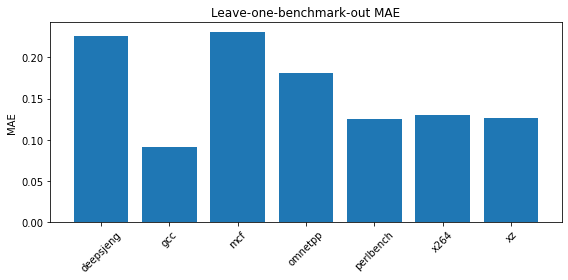

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(results_df["benchmark"], results_df["mae"])
plt.ylabel("MAE")
plt.title("Leave-one-benchmark-out MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


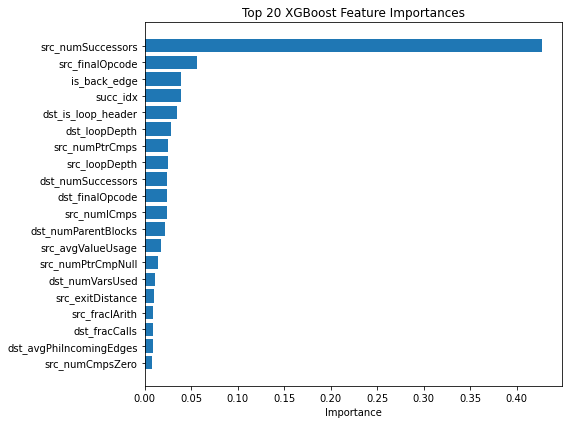

In [14]:
topk = 20
top_df = feature_importance_df.head(topk).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_df["feature"], top_df["importance"])
plt.xlabel("Importance")
plt.title(f"Top {topk} XGBoost Feature Importances")
plt.tight_layout()
plt.show()
